In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/pd_speech_features.csv')

# Basic info
print("--- Info ---")
print(df.info())

print("\n--- Total Missing Values ---")
print(df.isnull().sum().sum())

print("\n--- Target Variable 'class' Distribution ---")
if 'class' in df.columns:
    print(df['class'].value_counts())
else:
    print("Column 'class' not found. Target might be named differently.")
    print("Columns:", df.columns.tolist()[-5:])



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB
None

--- Total Missing Values ---
0

--- Target Variable 'class' Distribution ---
class
1    564
0    192
Name: count, dtype: int64


In [ ]:
import pandas as pd
df = pd.read_csv('/content/pd_speech_features.csv')
print(df.columns.tolist()[:10])
print(df['id'].head())

['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter']
0    0
1    0
2    0
3    1
4    1
Name: id, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

try:
    df = pd.read_csv('/content/pd_speech_features.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please upload the CSV to Colab.")

if 'id' in df.columns:
    df = df.drop('id', axis=1)

X = df.drop('class', axis=1)
y = df['class']

print(f"Original Class Balance:\n{y.value_counts()}\n")

# 4. Handle Data Imbalance (SMOTE)
# We generate synthetic data points for the "Healthy" (0) class so the model doesn't become biased
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Balanced Class Balance:\n{y_balanced.value_counts()}\n")

# 5. Split the Data (80% Train, 20% Test)
# stratify=y_balanced ensures the exact same ratio of patients in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# 6. Feature Scaling (Standardization)
# This dataset has 753 audio features (frequencies, jitters, MFCCs) all on completely different numerical scales.
# Scaling forces them into a standard range so no single feature dominates the model.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Preprocessing Complete ---")
print(f"Training Features Shape: {X_train_scaled.shape}")
print(f"Testing Features Shape: {X_test_scaled.shape}")
print(df.shape)

Dataset loaded successfully!
Original Class Balance:
class
1    564
0    192
Name: count, dtype: int64

Balanced Class Balance:
class
1    564
0    564
Name: count, dtype: int64

--- Preprocessing Complete ---
Training Features Shape: (902, 753)
Testing Features Shape: (226, 753)


1. Support Vector Machine (SVM)

--- Support Vector Machine (SVM) ---
Accuracy Score: 0.9425
ROC-AUC Score:  0.9904

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       113
           1       0.95      0.94      0.94       113

    accuracy                           0.94       226
   macro avg       0.94      0.94      0.94       226
weighted avg       0.94      0.94      0.94       226



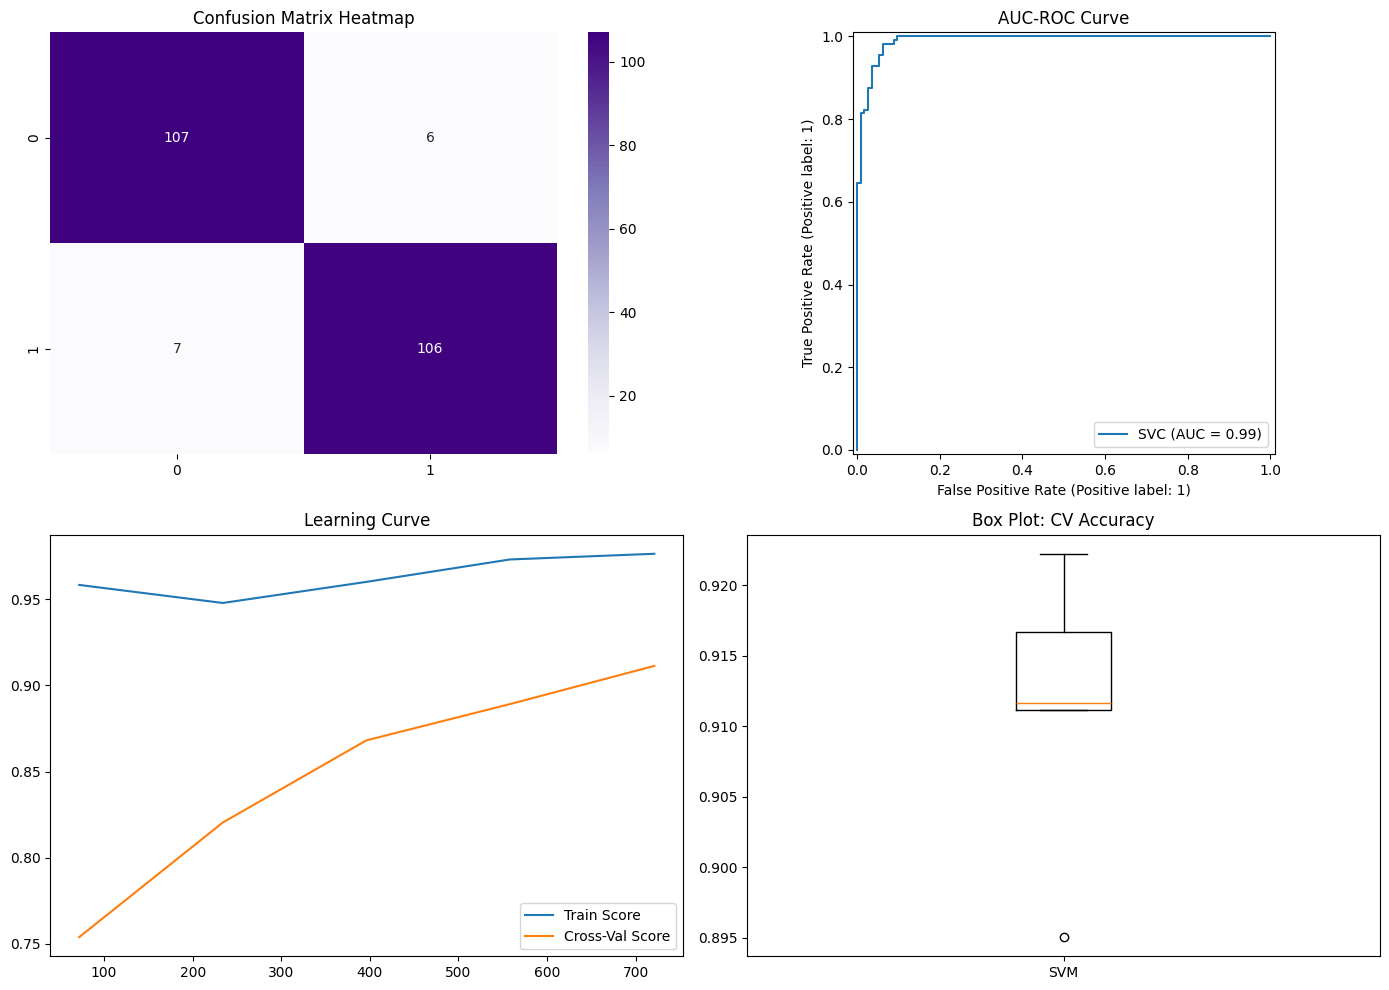

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import learning_curve, cross_val_score

# 1. Initialize and Train (probability=True is needed for ROC curve)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)

print("--- Support Vector Machine (SVM) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(svm_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(svm_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['SVM'])

plt.tight_layout()
plt.show()

2. XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:53:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:53:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

--- XGBoost ---
Accuracy Score: 0.9558
ROC-AUC Score:  0.9952

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       113
           1       0.97      0.94      0.95       113

    accuracy                           0.96       226
   macro avg       0.96      0.96      0.96       226
weighted avg       0.96      0.96      0.96       226



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:55:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:55:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:55:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:56:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

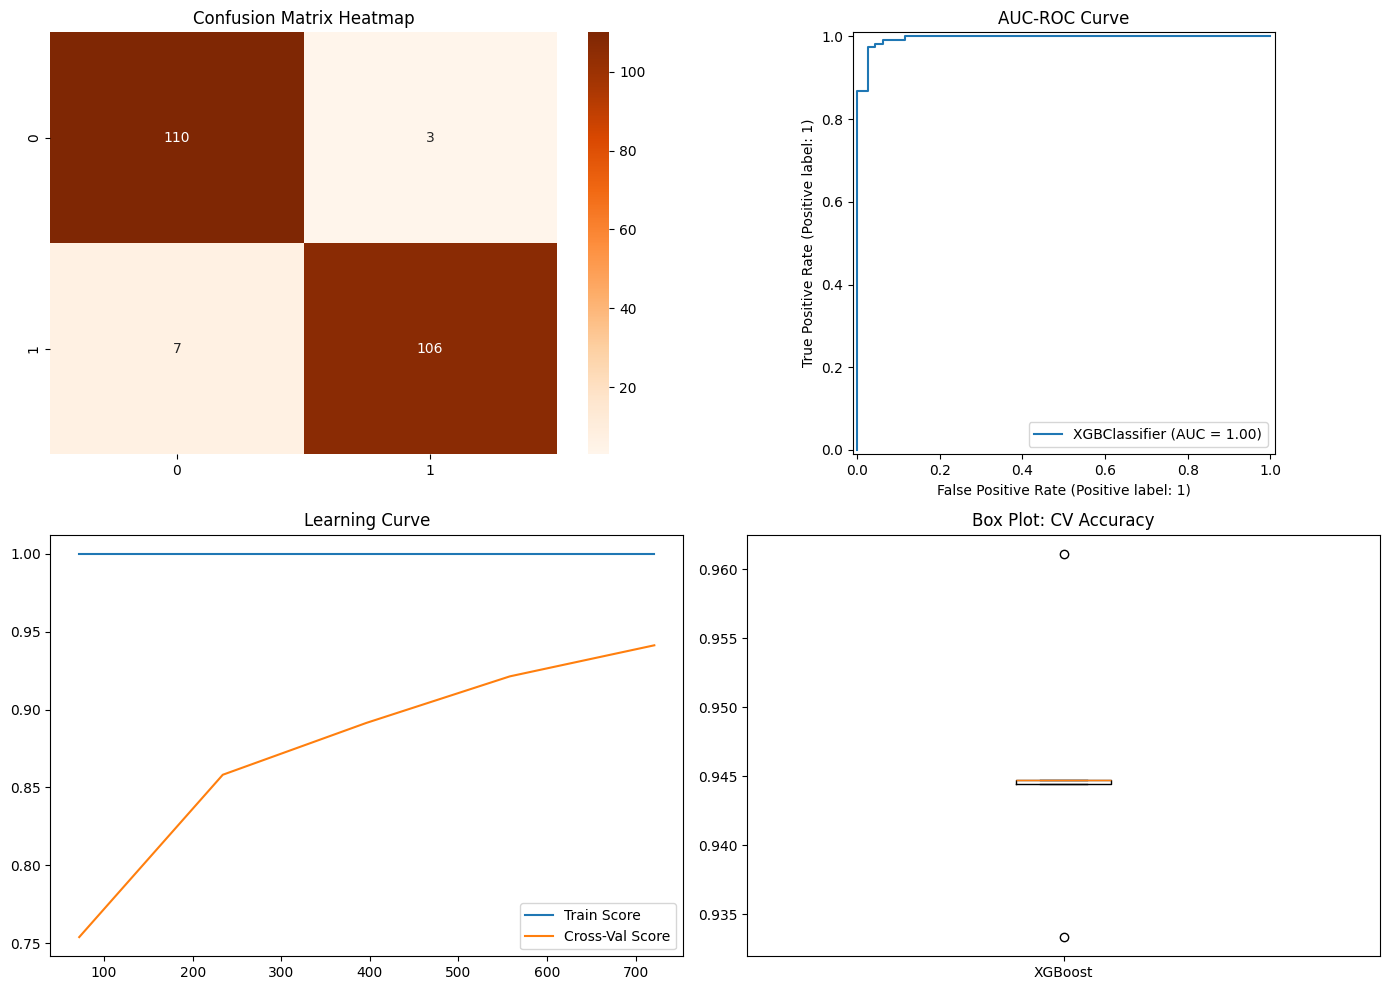

In [ ]:
from xgboost import XGBClassifier

# 1. Initialize and Train
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5)

print("--- XGBoost ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['XGBoost'])

plt.tight_layout()
plt.show()

3. K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize and Train
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)

print("--- K-Nearest Neighbors (KNN) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(knn_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['KNN'])

plt.tight_layout()
plt.show()

--- K-Nearest Neighbors (KNN) ---
Accuracy Score: 0.8009
ROC-AUC Score:  0.9594

Classification Report:
               precision    recall  f1-score   support

           0       0.72      1.00      0.83       113
           1       1.00      0.60      0.75       113

    accuracy                           0.80       226
   macro avg       0.86      0.80      0.79       226
weighted avg       0.86      0.80      0.79       226



4. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)

print("--- Random Forest ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(rf_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['Random Forest'])

plt.tight_layout()
plt.show()

5. Logistic Regression (The Clinical Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize and Train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)

print("--- Logistic Regression ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(log_reg, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['LogReg'])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# 1. Load the dataset
df = pd.read_csv('pd_speech_features.csv')

# Drop the 'id' column as it has no mathematical value
df = df.drop('id', axis=1)

print("--- STATISTICAL HYPOTHESIS TESTING (PARKINSON'S AUDIO) ---")

# --- 1. CHI-SQUARE TEST (For 'gender') ---
print("\n1. Chi-Square Test (Categorical Feature):")
contingency_table = pd.crosstab(df['gender'], df['class'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

if p_value < 0.05:
    print(f"  [SIGNIFICANT] gender: p-value = {p_value:.5f} -> Keep for ML model.")
else:
    print(f"  [NOT Significant] gender: p-value = {p_value:.5f} -> Consider dropping.")


# --- 2. MANN-WHITNEY U TEST (For the 752 Continuous Features) ---
print("\n2. Mann-Whitney U Tests with FDR Correction (Continuous Features):")

# Separate the groups
sick = df[df['class'] == 1]
healthy = df[df['class'] == 0]

# Get all continuous columns (everything except 'gender' and 'class')
continuous_cols = [col for col in df.columns if col not in ['gender', 'class']]

# Store raw p-values
raw_p_values = []

print(f"  Running tests on {len(continuous_cols)} audio features... please wait.")
for col in continuous_cols:
    stat, p_val = mannwhitneyu(sick[col], healthy[col], alternative='two-sided')
    raw_p_values.append(p_val)

# --- 3. APPLY FALSE DISCOVERY RATE (FDR) CORRECTION ---
# This corrects the p-values to prevent False Positives caused by having so many columns
reject, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

# Count how many features actually survived the strict correction
significant_features = []
for i, col in enumerate(continuous_cols):
    if reject[i]: # If True, the feature is statistically significant
        significant_features.append(col)

print(f"\n--- FEATURE SELECTION RESULTS ---")
print(f"Total Continuous Features Tested: {len(continuous_cols)}")
print(f"Statistically Significant Features (Kept): {len(significant_features)}")
print(f"Insignificant Features (Dropped): {len(continuous_cols) - len(significant_features)}")

# Display the top 5 most significant features as an example
# (Sorting by lowest corrected p-value)
top_features_indices = np.argsort(pvals_corrected)[:5]
print("\nTop 5 Most Powerful Predictors of Parkinson's:")
for idx in top_features_indices:
    print(f"  - {continuous_cols[idx]} (Corrected p-value: {pvals_corrected[idx]:.5e})")

# OPTIONAL: Create your finalized dataset containing ONLY the significant features
final_features = ['class']
if p_value < 0.05:
    final_features.append('gender')
final_features.extend(significant_features)

df_optimized = df[final_features]
print(f"\nFinal Optimized Dataset Shape ready for ML: {df_optimized.shape}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

print("--- PREPARING OPTIMIZED DATA ---")

# 1. Separate Features and Target from your optimized dataset
X_opt = df_optimized.drop('class', axis=1)
y_opt = df_optimized['class']

# 2. Balance the Data with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_opt, y_opt)

# 3. Split the Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# 4. Feature Scaling (Crucial for SVM and high-dimensional data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print("Data is scaled, balanced, and ready!\n")

print("--- TRAINING TOP MODELS ---")

# Initialize the 3 Best Models for High-Dimensional Data
models = {
    "Support Vector Machine (SVM)": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False, n_jobs=-1)
}

results = {}

# Train and Evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {'Accuracy': acc, 'ROC-AUC': roc, 'y_pred': y_pred}

    print(f"\n{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  ROC-AUC:  {roc:.4f}")

# --- VISUALIZING THE BEST MODEL'S CONFUSION MATRIX ---
# Find the model with the highest Accuracy
best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
best_predictions = results[best_model_name]['y_pred']

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, best_predictions), annot=True, fmt='d', cmap='magma')
plt.title(f"Best Model Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(f"\nWinner: {best_model_name}!")

--- PREPARING OPTIMIZED DATA ---
Data successfully scaled and balanced!

Starting Hybrid Model Training... (This may take 1-3 minutes due to high dimensionality)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Completed in 132.20 seconds!

--- HYBRID MODEL EVALUATION ---
Accuracy Score: 0.9602
ROC-AUC Score:  0.9965

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       113
           1       0.98      0.94      0.96       113

    accuracy                           0.96       226
   macro avg       0.96      0.96      0.96       226
weighted avg       0.96      0.96      0.96       226



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


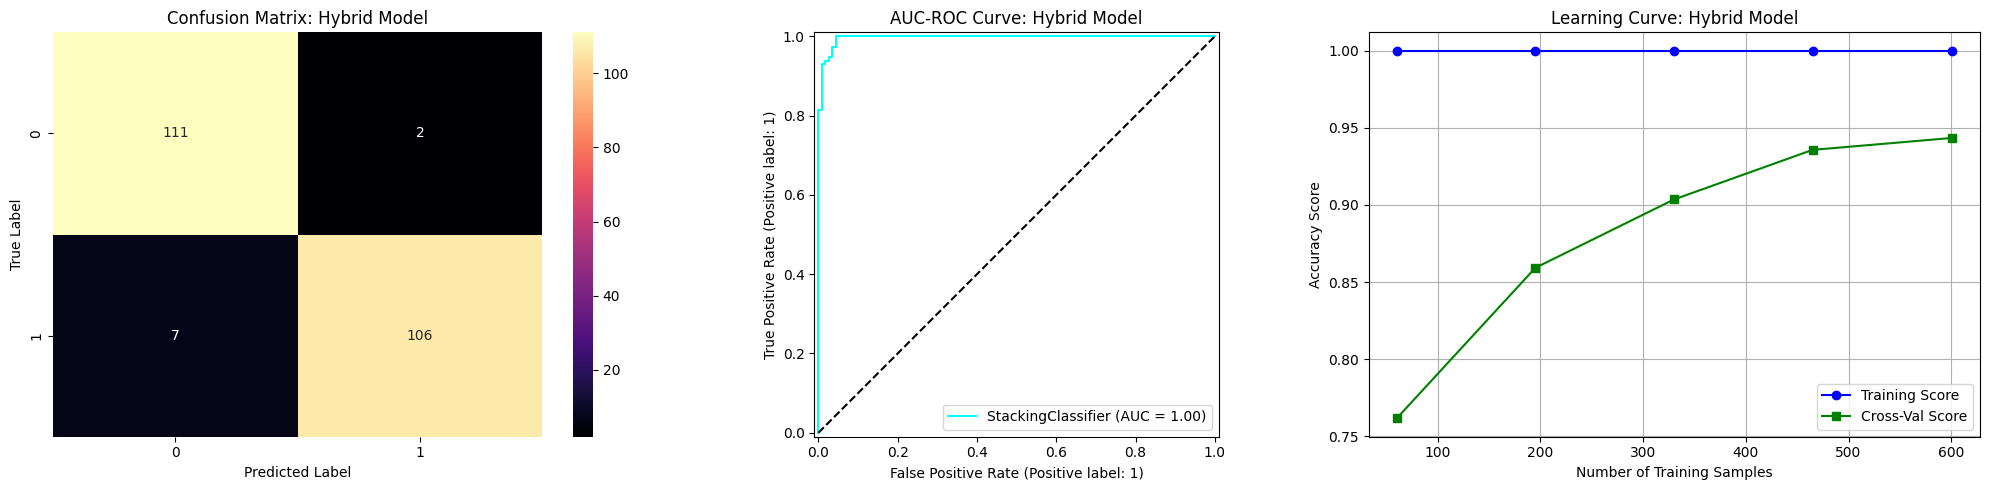

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay

# Import Machine Learning Models
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

print("--- PREPARING OPTIMIZED DATA ---")
# 1. Assuming 'df_optimized' is available from your previous Hypothesis Testing step
X_opt = df_optimized.drop('class', axis=1)
y_opt = df_optimized['class']

# 2. Balance the data using SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_opt, y_opt)

# 3. Split the Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# 4. Feature Scaling (Crucial for Audio/Vocal Data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled and balanced!\n")
print("Starting Hybrid Model Training... (This may take 1-3 minutes due to high dimensionality)\n")
start_time = time.time()

# --- BUILDING THE HYBRID STACKING MODEL ---

# 1. Define the Base Models (Level 0)
# We use n_jobs=-1 to force Google Colab to use all available CPU cores for maximum speed
base_models = [
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=150, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1))
]

# 2. Define the Meta-Model (Level 1)
# Logistic Regression acts as the "Doctor" analyzing the opinions of the 4 "Specialist" base models
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# 3. Initialize and Train the Stacking Classifier
# cv=5 ensures the base models are rigorously cross-validated before passing predictions to the meta-model
hybrid_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)
hybrid_model.fit(X_train_scaled, y_train)

# 4. Predictions & Metrics
y_pred = hybrid_model.predict(X_test_scaled)
y_prob = hybrid_model.predict_proba(X_test_scaled)[:, 1]

end_time = time.time()
print(f"Training Completed in {(end_time - start_time):.2f} seconds!")

print("\n--- HYBRID MODEL EVALUATION ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- ADVANCED VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Visualization 1: Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma', ax=axes[0])
axes[0].set_title("Confusion Matrix: Hybrid Model")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Visualization 2: AUC-ROC Curve
RocCurveDisplay.from_estimator(hybrid_model, X_test_scaled, y_test, ax=axes[1], color='cyan')
axes[1].plot([0, 1], [0, 1], 'k--') # Diagonal reference line
axes[1].set_title("AUC-ROC Curve: Hybrid Model")

# Visualization 3: Learning Curve
# Uses cv=3 to render faster. Proves the model isn't memorizing the audio features.
train_sizes, train_scores, test_scores = learning_curve(
    hybrid_model, X_train_scaled, y_train, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)
axes[2].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score', color='blue')
axes[2].plot(train_sizes, np.mean(test_scores, axis=1), 's-', label='Cross-Val Score', color='green')
axes[2].set_title("Learning Curve: Hybrid Model")
axes[2].set_xlabel("Number of Training Samples")
axes[2].set_ylabel("Accuracy Score")
axes[2].legend(loc="best")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
from google.colab import files

# 1. Save the model and scaler to Colab's temporary memory
joblib.dump(hybrid_model, 'parkinsons_model.pkl')
joblib.dump(scaler, 'parkinsons_scaler.pkl')
print("Files saved to Colab. Starting download to your computer...")

# 2. Force the browser to download them directly to your computer
files.download('parkinsons_model.pkl')
files.download('parkinsons_scaler.pkl')

Files saved to Colab. Starting download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
# Assuming your Parkinson's testing data is called X_test
real_sample_patient = X_test.iloc[[0]]
real_sample_patient.to_csv('parkinsons_sample.csv', index=False)
files.download('parkinsons_sample.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>